In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv("airbnb_cleaned.csv", low_memory=False)

print("Shape:", df.shape)
df.head()

Shape: (101811, 28)


,id,name,host_id,host_identity_verified,host_name,neighbourhood_group,neighbourhood,lat,long,country,...,number_of_reviews,last_review,reviews_per_month,review_rate_number,calculated_host_listings_count,availability_365,review_year,review_month,host_type,price_category
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,9.0,2021-10-19,0.21,4.0,6.0,286.0,2021.0,10.0,professional,High
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,45.0,2022-05-21,0.38,4.0,2.0,228.0,2022.0,5.0,casual,Low
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,unconfirmed,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,0.0,NaN,0.74,5.0,1.0,352.0,NaN,NaN,casual,Medium
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,270.0,2019-07-05,4.64,4.0,1.0,322.0,2019.0,7.0,casual,Low
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,9.0,2018-11-19,0.10,3.0,1.0,289.0,2018.0,11.0,casual,Low


In [2]:
print(df.info())
print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False).head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101811 entries, 0 to 101810
Data columns (total 28 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              101811 non-null  int64  
 1   name                            101564 non-null  object 
 2   host_id                         101811 non-null  int64  
 3   host_identity_verified          101811 non-null  object 
 4   host_name                       101412 non-null  object 
 5   neighbourhood_group             101811 non-null  object 
 6   neighbourhood                   101796 non-null  object 
 7   lat                             101803 non-null  float64
 8   long                            101803 non-null  float64
 9   country                         101284 non-null  object 
 10  country_code                    101685 non-null  object 
 11  instant_bookable                101811 non-null  bool   
 12  cancellation_pol

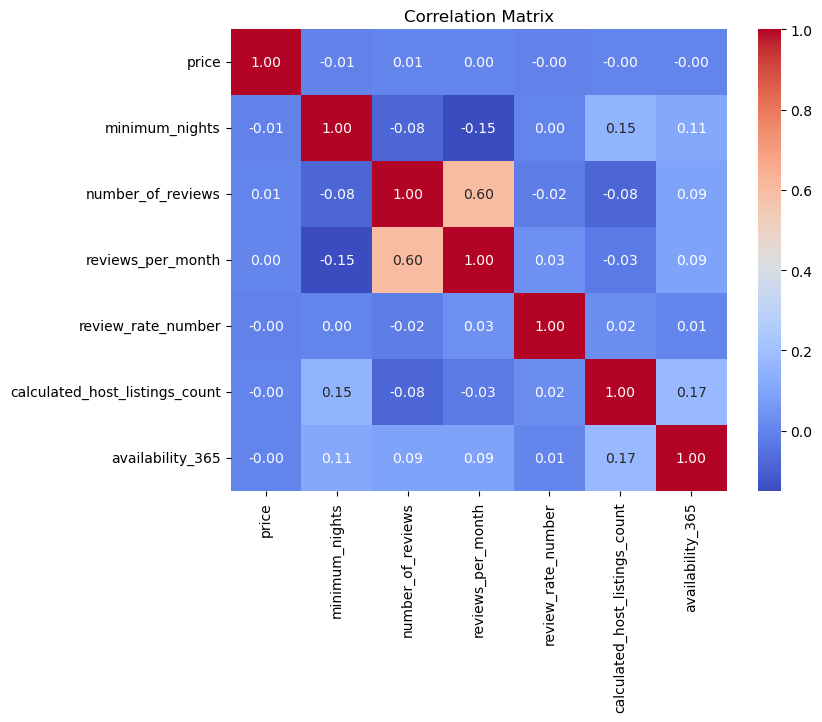

In [3]:
corr_cols = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "review_rate_number",
    "calculated_host_listings_count",
    "availability_365",
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

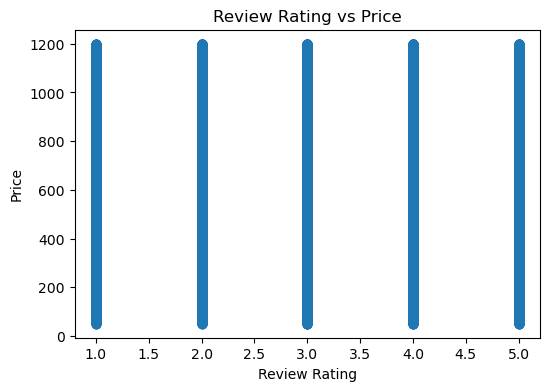

In [4]:
plt.figure(figsize=(6,4))
plt.scatter(df["review_rate_number"], df["price"], alpha=0.3)
plt.xlabel("Review Rating")
plt.ylabel("Price")
plt.title("Review Rating vs Price")
plt.show()

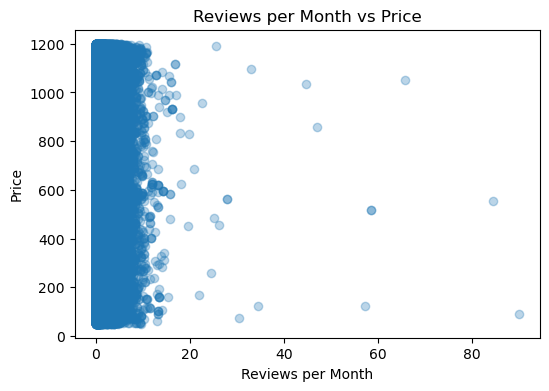

In [5]:
plt.figure(figsize=(6,4))
plt.scatter(df["reviews_per_month"], df["price"], alpha=0.3)
plt.xlabel("Reviews per Month")
plt.ylabel("Price")
plt.title("Reviews per Month vs Price")
plt.show()

In [8]:
print(df["price"].describe())

count    101811.000000
mean        625.355580
std         331.672649
min          50.000000
25%         340.000000
50%         625.000000
75%         913.000000
max        1200.000000
Name: price, dtype: float64


neighbourhood_group
Queens           630.217031
Bronx            627.764793
Brooklyn         626.500843
Staten Island    623.990486
Manhattan        622.670186
Name: price, dtype: float64


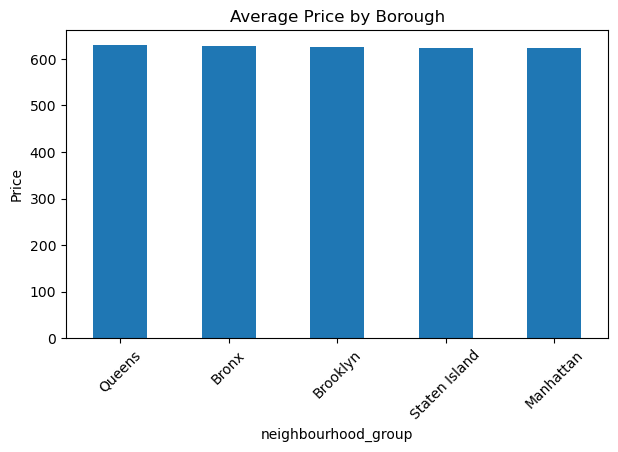

In [6]:
avg_price_borough = (
    df.groupby("neighbourhood_group")["price"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_price_borough)

avg_price_borough.plot(kind="bar", figsize=(7,4))
plt.title("Average Price by Borough")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.show()

room_type
Hotel room         666.391304
Shared room        634.828182
Entire home/apt    625.240056
Private room       624.935628
Name: price, dtype: float64


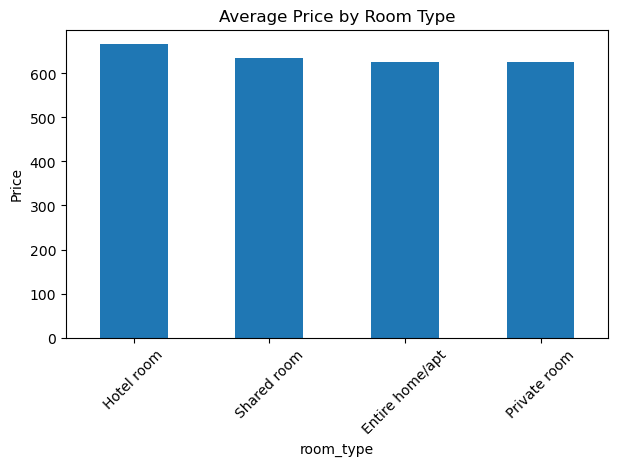

In [7]:
avg_price_room = (
    df.groupby("room_type")["price"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_price_room)

avg_price_room.plot(kind="bar", figsize=(7,4))
plt.title("Average Price by Room Type")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.show()

In [11]:
borough_stats = (
    df.groupby("neighbourhood_group")["price"]
    .agg(["min", "max", "mean", "median", "std"])
    .sort_values("mean", ascending=False)
)

borough_stats["range"] = borough_stats["max"] - borough_stats["min"]
borough_stats

,min,max,mean,median,std,range
neighbourhood_group,,,,,,
Queens,50.0,1200.0,630.217031,628.0,334.146376,1150.0
Bronx,50.0,1200.0,627.764793,632.0,323.814102,1150.0
Brooklyn,50.0,1200.0,626.500843,626.0,331.937562,1150.0
Staten Island,50.0,1200.0,623.990486,628.0,325.783177,1150.0
Manhattan,50.0,1200.0,622.670186,621.5,331.265186,1150.0
